# Compare annotation performance

In [1]:
import os.path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
import os
from pathlib import Path
from anndata.compat import DaskArray
import dask.array as da
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE
from pathlib import Path

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
models_path = Path("/g/stegle/aalsayah/repos/inflow_score_different_annotation/models")

In [3]:
model_jst = mfl.MOFAFLEX.load(models_path / "model_jst")

In [4]:
model_lv1 = mfl.MOFAFLEX.load(models_path / "model_level1")

In [5]:
model_lv2 = mfl.MOFAFLEX.load(models_path / "model_level2")

In [6]:
model_ist = mfl.MOFAFLEX.load(models_path / "model_ist")

In [7]:
data_path = Path("/g/stegle/aalsayah/repos/inflow_score_different_annotation")

In [8]:
lrdata = sc.read_h5ad(data_path/ "inflow_score_ist.h5ad")

In [9]:
lv1 = lrdata.obs["lv1"]

In [10]:
lv2 = lrdata.obs["lv2"]

In [11]:
ist = lrdata.obs["ist"]

In [12]:
typ = lrdata.obs["typ"]

# Cluster by factor score

In [24]:
factors = model_ist.get_factors()

In [25]:
factors = factors["group_1"]

In [26]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_154_37,0.085426,0.134153,0.951666,-0.497316,-0.908589,-0.374591,-0.036147,-0.632263,0.179662,-0.087831,-0.317096,-0.290400,-0.670909,1.052463,-0.250754
c_3_154_43,0.302522,-0.037855,0.501170,-0.022138,-0.543980,0.097037,-0.099786,-0.351762,0.008662,1.159221,-0.241143,0.153900,-0.198234,0.412840,0.055381
c_3_154_61,-0.178582,-0.472574,0.582427,-0.283238,-0.009777,0.253981,-0.307251,-0.313131,0.294228,0.738428,0.273614,-0.370328,-0.259083,-0.293352,0.146010
c_3_154_69,-0.112379,-0.095783,-0.310092,0.297999,-0.333418,-0.149187,-0.224769,-0.034862,0.064551,0.672257,0.390976,-0.094665,0.313243,-0.067890,0.682875
c_3_154_75,-0.106441,0.214625,-0.231379,-0.212068,-0.355736,-0.345462,-0.624809,0.272327,0.323879,0.334184,0.059619,0.217701,0.450128,-0.164670,0.732304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_163_214,0.684093,-0.017714,0.160284,-0.627853,-0.033214,-0.165567,-0.473106,0.214921,-0.229451,-0.405425,-0.873117,0.506321,-0.227506,0.103612,0.684636
c_3_163_1843,-0.731374,-0.928795,1.742167,-0.319425,-0.465075,0.914405,1.006776,-1.343212,-0.962664,0.106438,1.183348,1.612215,0.053374,0.464126,-0.404423
c_3_163_2575,0.756079,-0.996664,-0.594713,-0.554859,-0.038884,-0.083340,0.220243,0.441358,-1.049753,-0.408831,-0.202613,0.400399,-0.462341,-0.193502,-0.109384
c_3_164_158,-0.895086,-0.670308,-0.687510,0.233258,1.254605,0.189812,0.107237,-1.204187,0.059344,-0.171521,0.116399,-0.873648,-0.580078,-0.764911,0.933357


## Metadata

In [27]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(20377,)

In [28]:
lv2 = lv2.loc[lv2.index.intersection(factors.index)]
lv2 = lv2.reindex(factors.index)
lv2.shape

(20377,)

In [29]:
typ = lrdata.obs["ctx"]
typ = typ.loc[typ.index.intersection(factors.index)]
typ = typ.reindex(factors.index)
typ.shape

(20377,)

# Heatmap (view x LR)

In [46]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [14]:
weights = model_ist.get_weights()

In [51]:
weights.items()

dict_items([('EC',            EC^CEACAM1^CEACAM5  EC^MDK^NCL  EC^APP^CD74  EC^PDGFA^PDGFRB  \
Factor 1             0.000787    0.012454     0.215195         0.012229   
Factor 2             0.002108   -0.003136    -0.050894        -0.011238   
Factor 3            -0.004199   -0.028130     0.090651         0.003401   
Factor 4            -0.003222   -0.000170    -0.062682         0.000970   
Factor 5            -0.008009   -0.039196    -0.166701        -0.001431   
Factor 6             0.008040    0.004715     0.019260        -0.007806   
Factor 7            -0.001425    0.008479     0.141293         0.013601   
Factor 8             0.006539    0.035531     0.184246         0.017374   
Factor 9             0.002488   -0.012392    -0.124671        -0.016246   
Factor 10            0.006109    0.030354     0.060723         0.013177   
Factor 11           -0.015523   -0.066661    -0.186521        -0.006120   
Factor 12           -0.000723   -0.011261    -0.104167        -0.016960   
Factor

In [57]:
s.index

Index(['CEACAM1^CEACAM5', 'MDK^NCL', 'APP^CD74', 'FN1^CD44', 'SPP1^CD44',
       'LGALS9^CD44', 'FN1^SDC4', 'COL6A1^SDC4', 'COL4A2^SDC4', 'THBS2^CD47',
       'THBS1^CD47', 'COL6A1^CD44', 'MDK^SDC4', 'COL1A2^SDC4', 'COL1A1^SDC4',
       'TNC^SDC4', 'COL6A2^SDC4', 'COL6A3^CD44', 'THBS2^SDC4', 'COL6A2^CD44',
       'COL4A2^CD44', 'COL4A1^SDC4', 'COL1A2^CD44', 'COL6A3^SDC4',
       'COL1A1^CD44', 'LAMC2^CD44', 'THBS1^SDC4', 'GDF15^TGFBR2',
       'COL4A1^CD44', 'COMP^SDC4', 'LAMB1^CD44', 'LAMA4^CD44', 'COL4A2^SDC1',
       'COMP^CD47', 'MIF^CD44_CD74', 'FN1^SDC1', 'MDK^SDC1', 'THBS2^SDC1',
       'PDGFA^PDGFRB', 'COL6A1^SDC1', 'COL1A2^SDC1', 'THBS1^SDC1',
       'COL6A2^SDC1', 'COL6A3^SDC1', 'COL4A1^SDC1', 'COL1A1^SDC1', 'COMP^SDC1',
       'TNC^SDC1', 'EFNA1^EPHA2'],
      dtype='object')

In [49]:
 s

CEACAM1^CEACAM5    0.014045
MDK^NCL            0.038851
APP^CD74          -0.016713
FN1^CD44          -0.587985
SPP1^CD44         -0.787735
LGALS9^CD44       -0.072348
FN1^SDC4           0.822663
COL6A1^SDC4        0.224227
COL4A2^SDC4        0.117266
THBS2^CD47         0.095548
THBS1^CD47         0.103328
COL6A1^CD44        0.022729
MDK^SDC4           0.108611
COL1A2^SDC4        0.471784
COL1A1^SDC4        1.309932
TNC^SDC4           0.103309
COL6A2^SDC4        0.223607
COL6A3^CD44        0.076226
THBS2^SDC4         0.112366
COL6A2^CD44        0.050959
COL4A2^CD44        0.069625
COL4A1^SDC4        0.150619
COL1A2^CD44        0.225876
COL6A3^SDC4        0.249034
COL1A1^CD44        0.241682
LAMC2^CD44        -0.022712
THBS1^SDC4         0.144892
GDF15^TGFBR2       0.012118
COL4A1^CD44        0.077287
COMP^SDC4          0.058851
LAMB1^CD44         0.030504
LAMA4^CD44         0.030676
COL4A2^SDC1       -0.050757
COMP^CD47          0.029077
MIF^CD44_CD74     -0.151295
FN1^SDC1          -0

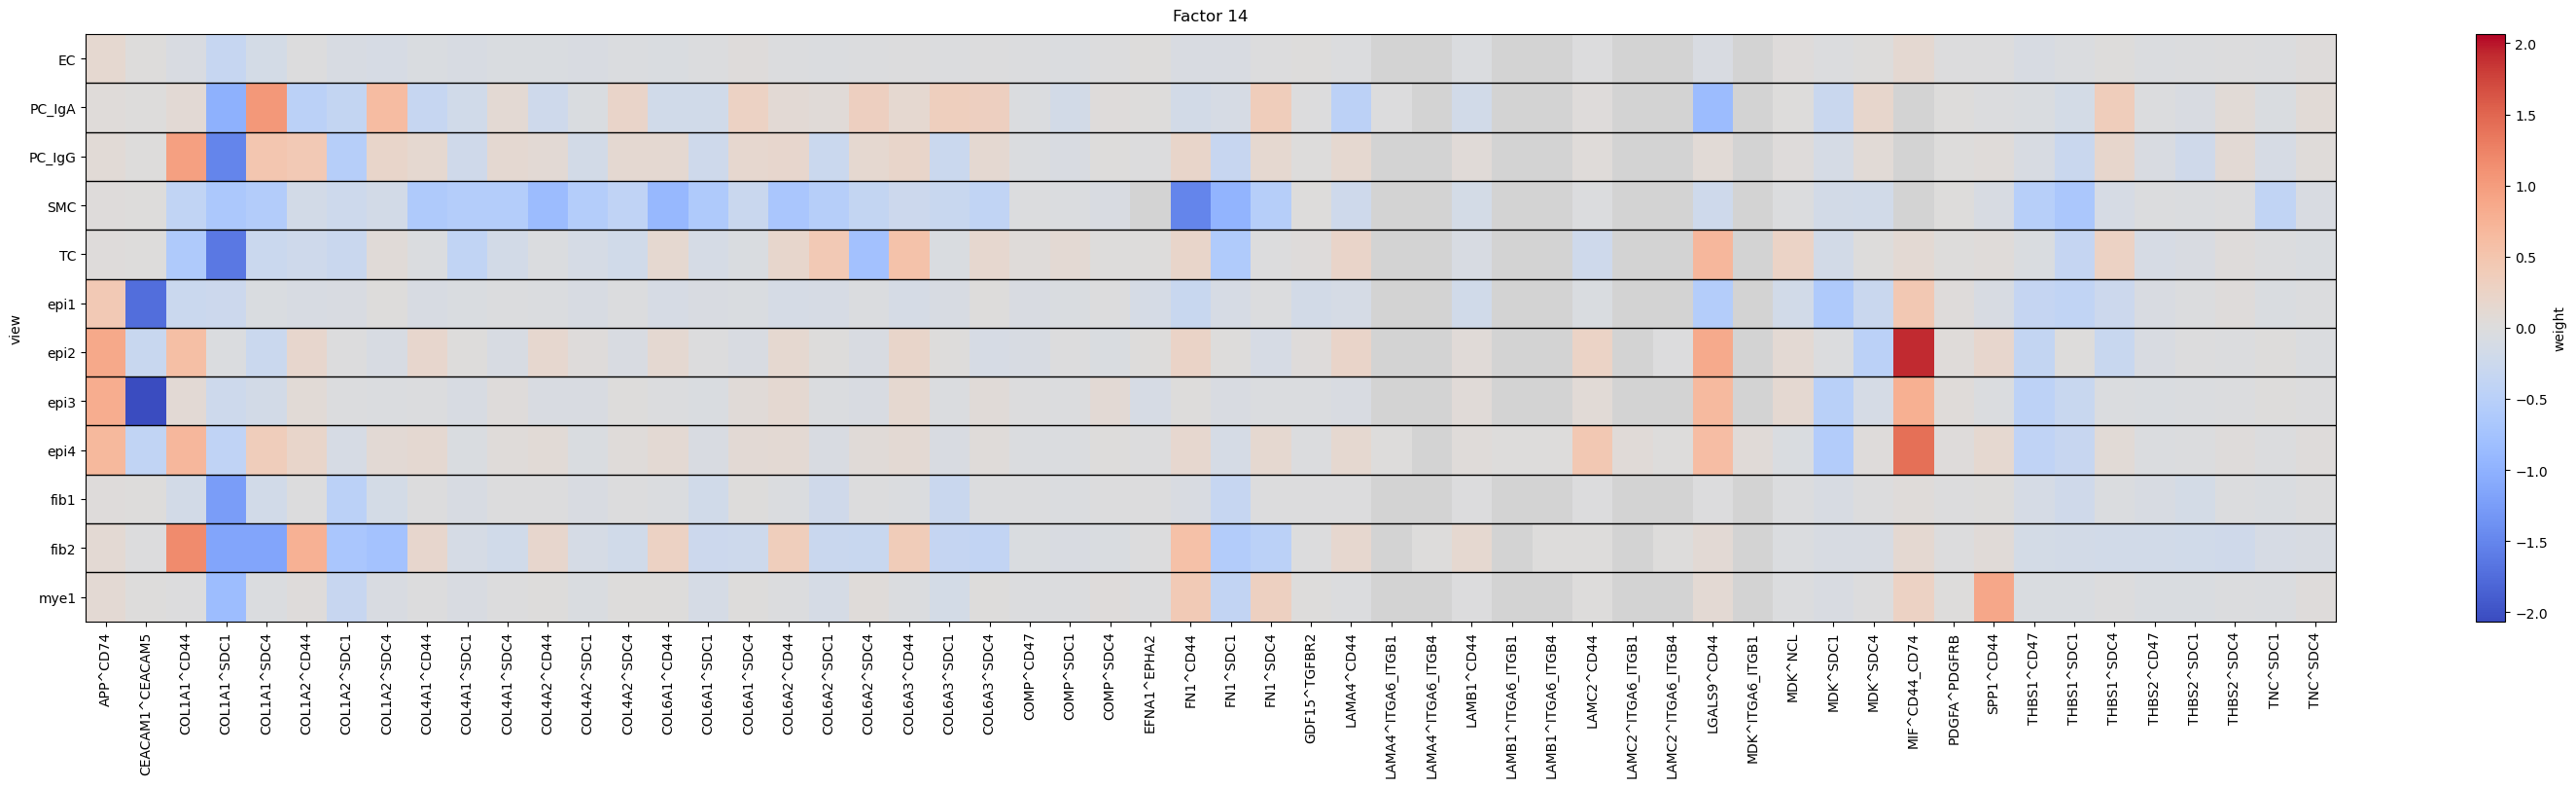

In [73]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 14          # or "3" or "Factor 3"

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


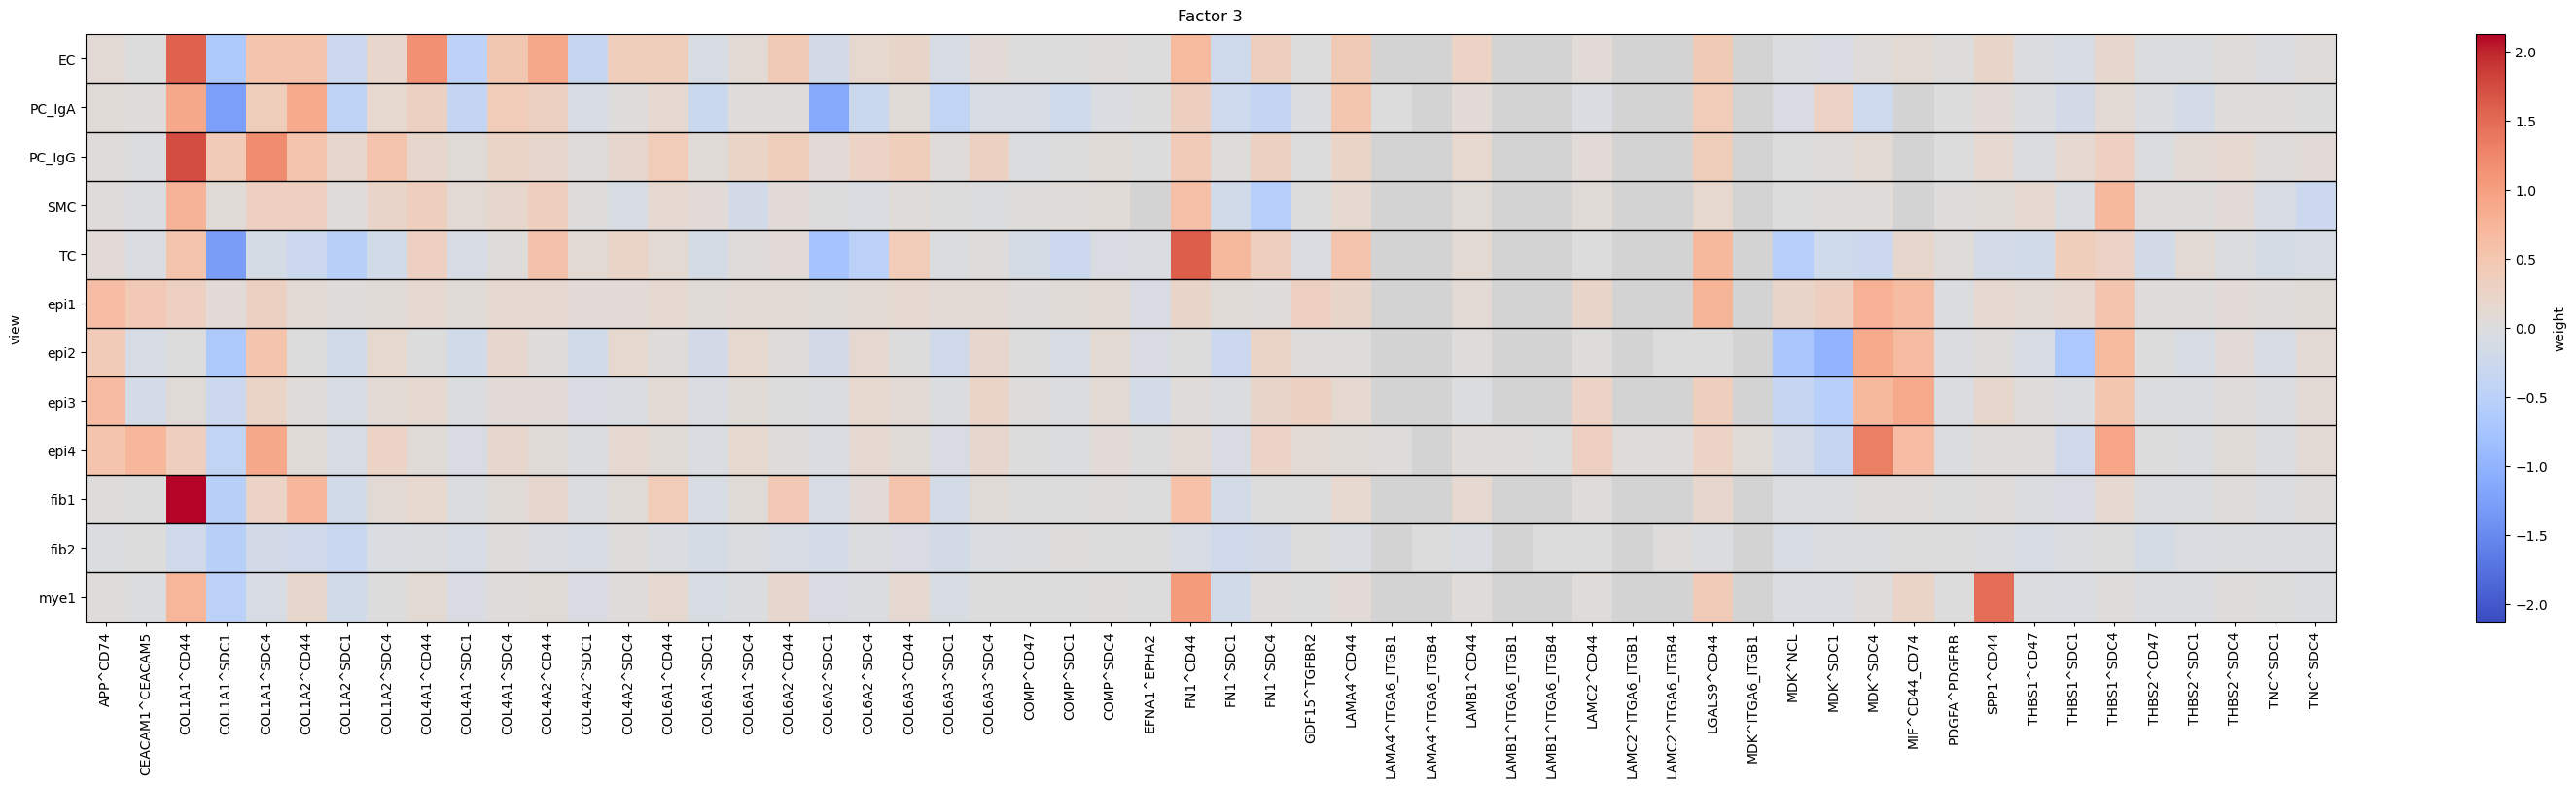

In [74]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 3          # or "3" or "Factor 3"

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


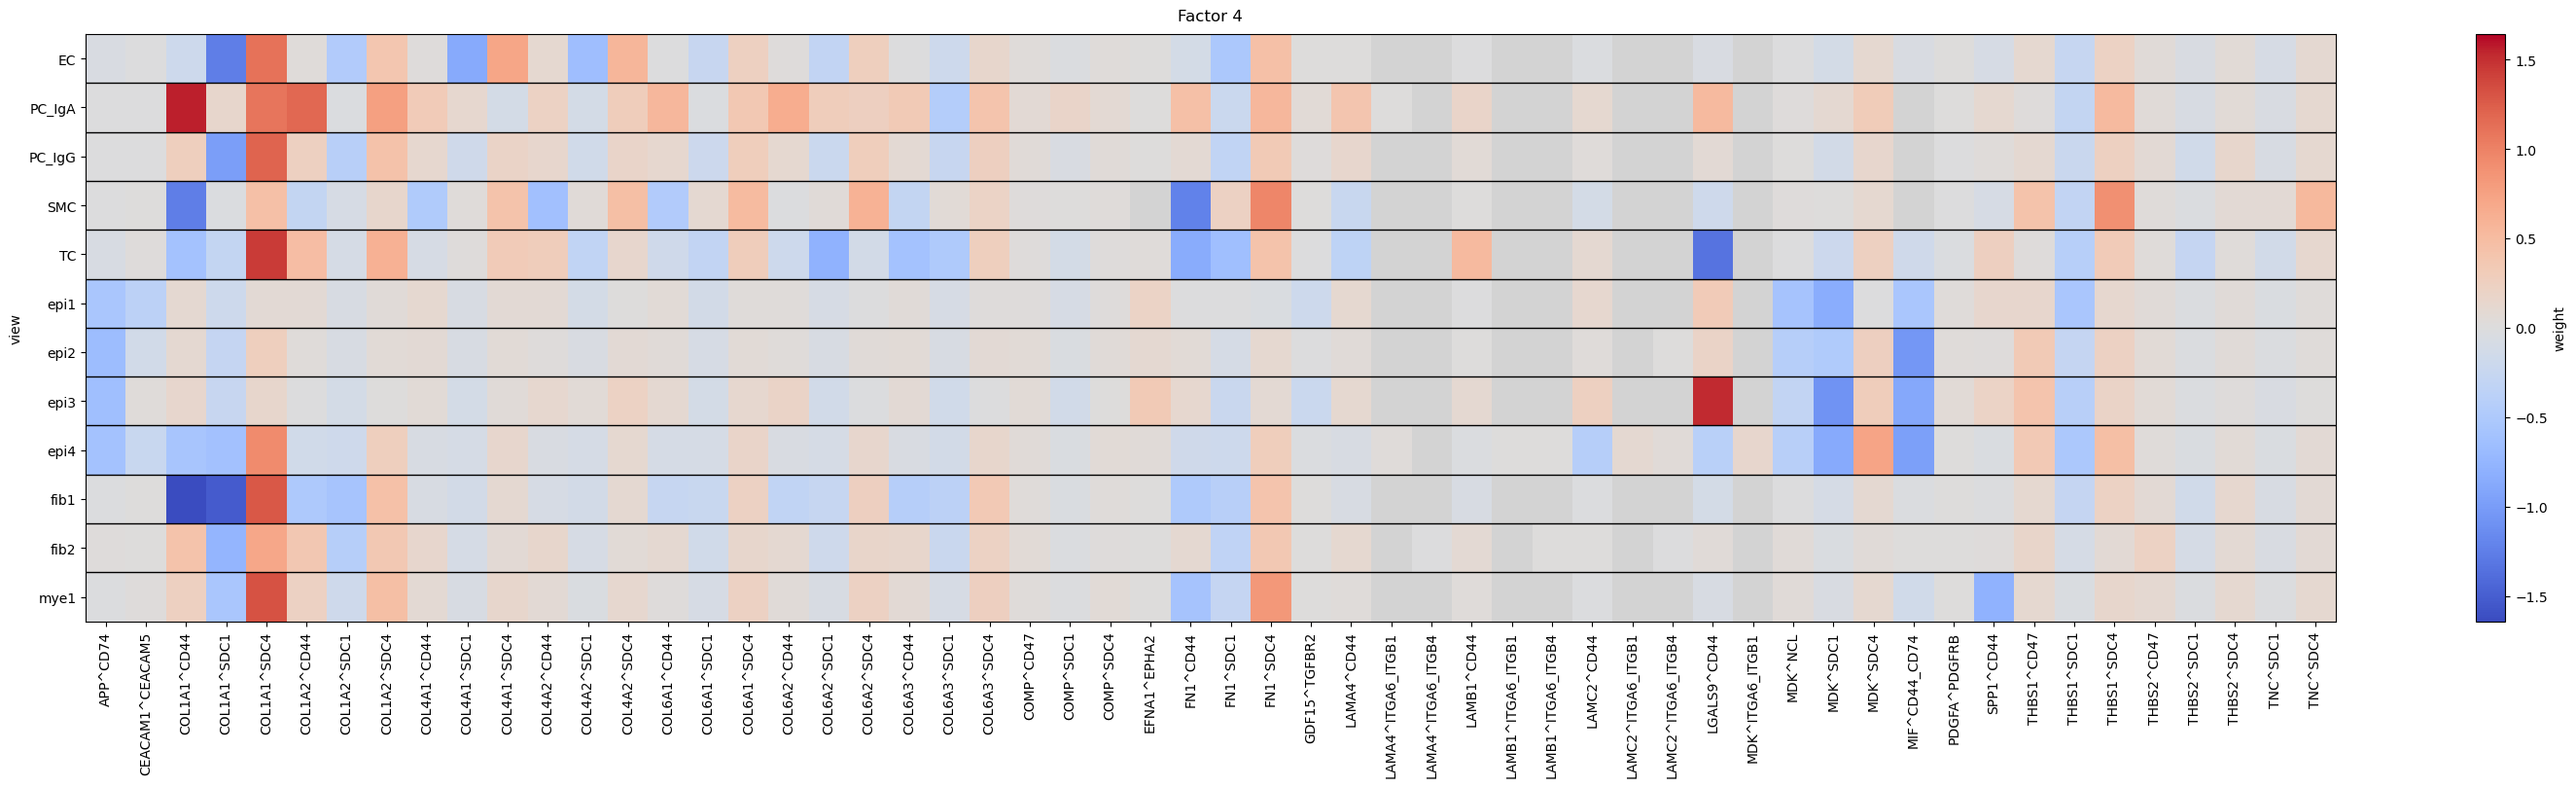

In [72]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 4           # or "3" or "Factor 3"

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


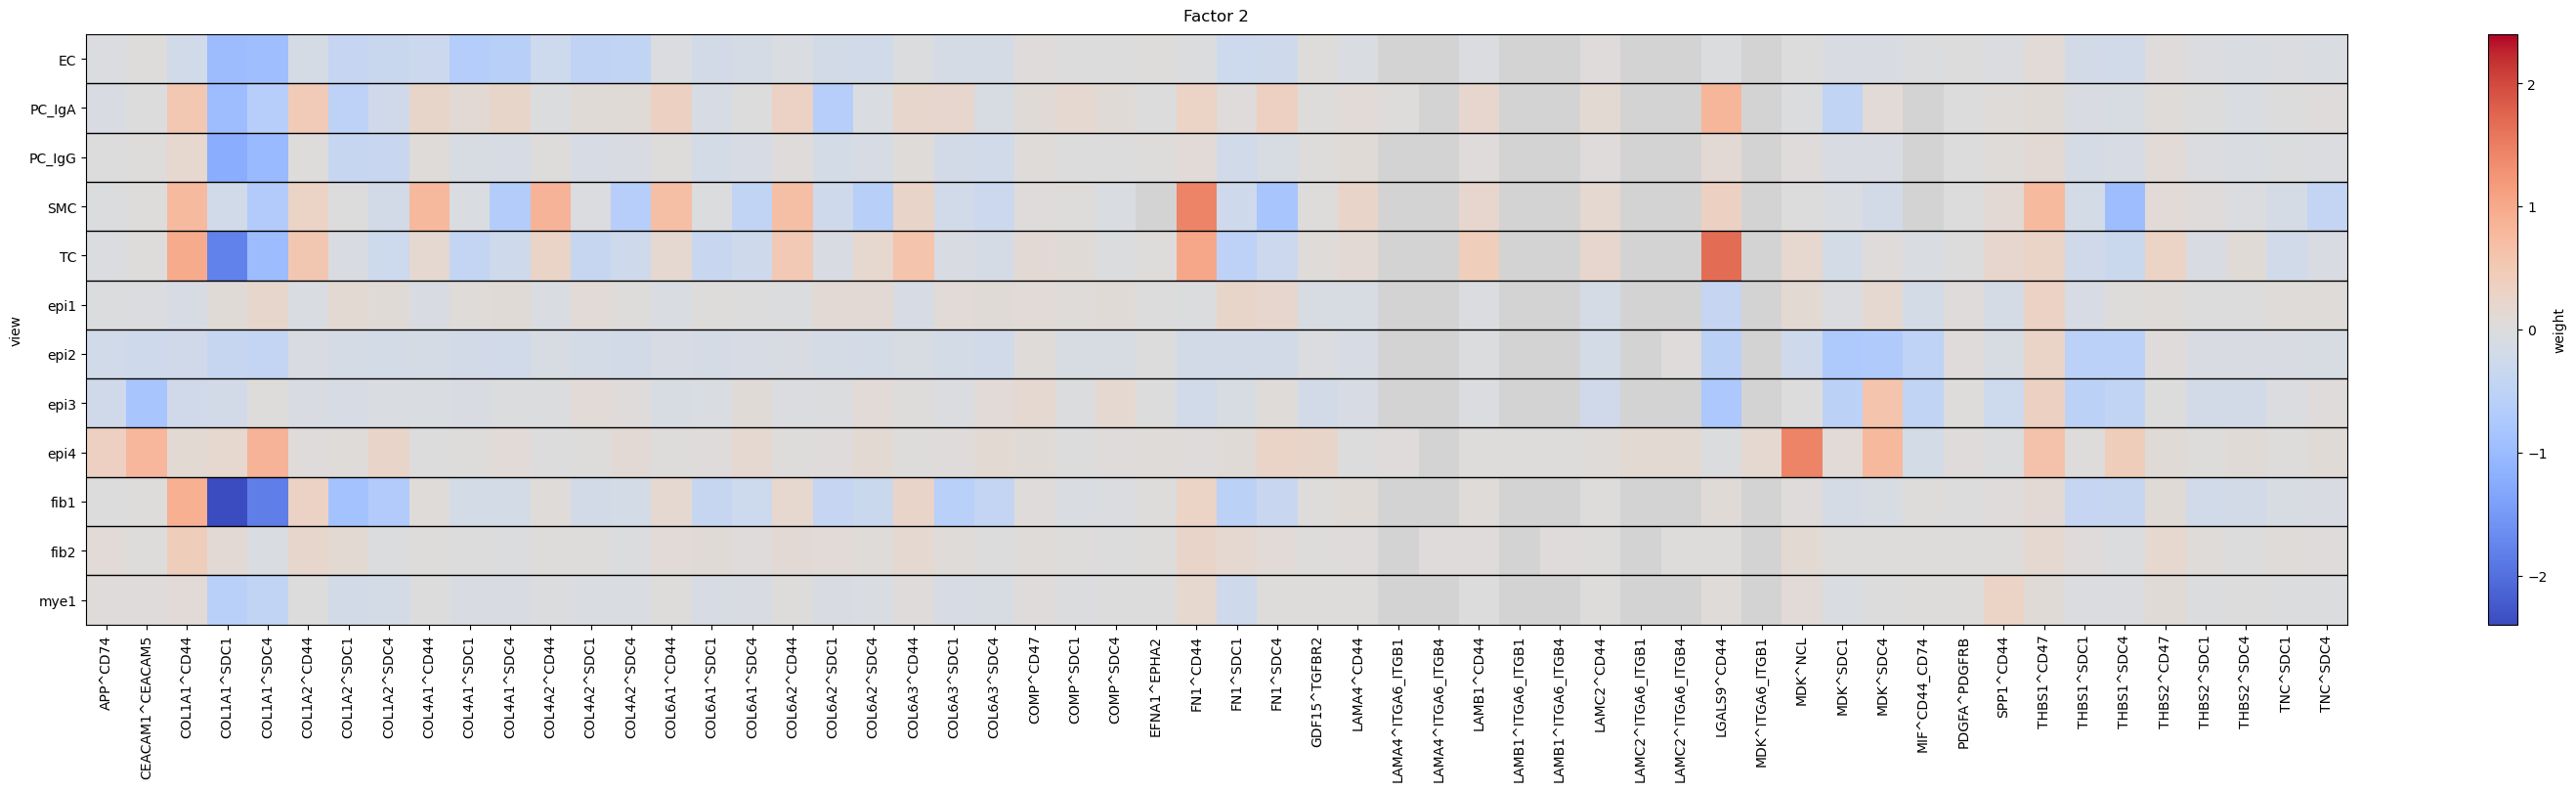

In [65]:
k = 2  # Factor number (1-based)

rows, labels = [], []
for view, df in weights.items():
    s = df.iloc[k-1].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view) 

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# symmetric range + center at 0
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

# (optional) show NaNs in a neutral color
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {k}", pad=10)
plt.tight_layout()
plt.show()


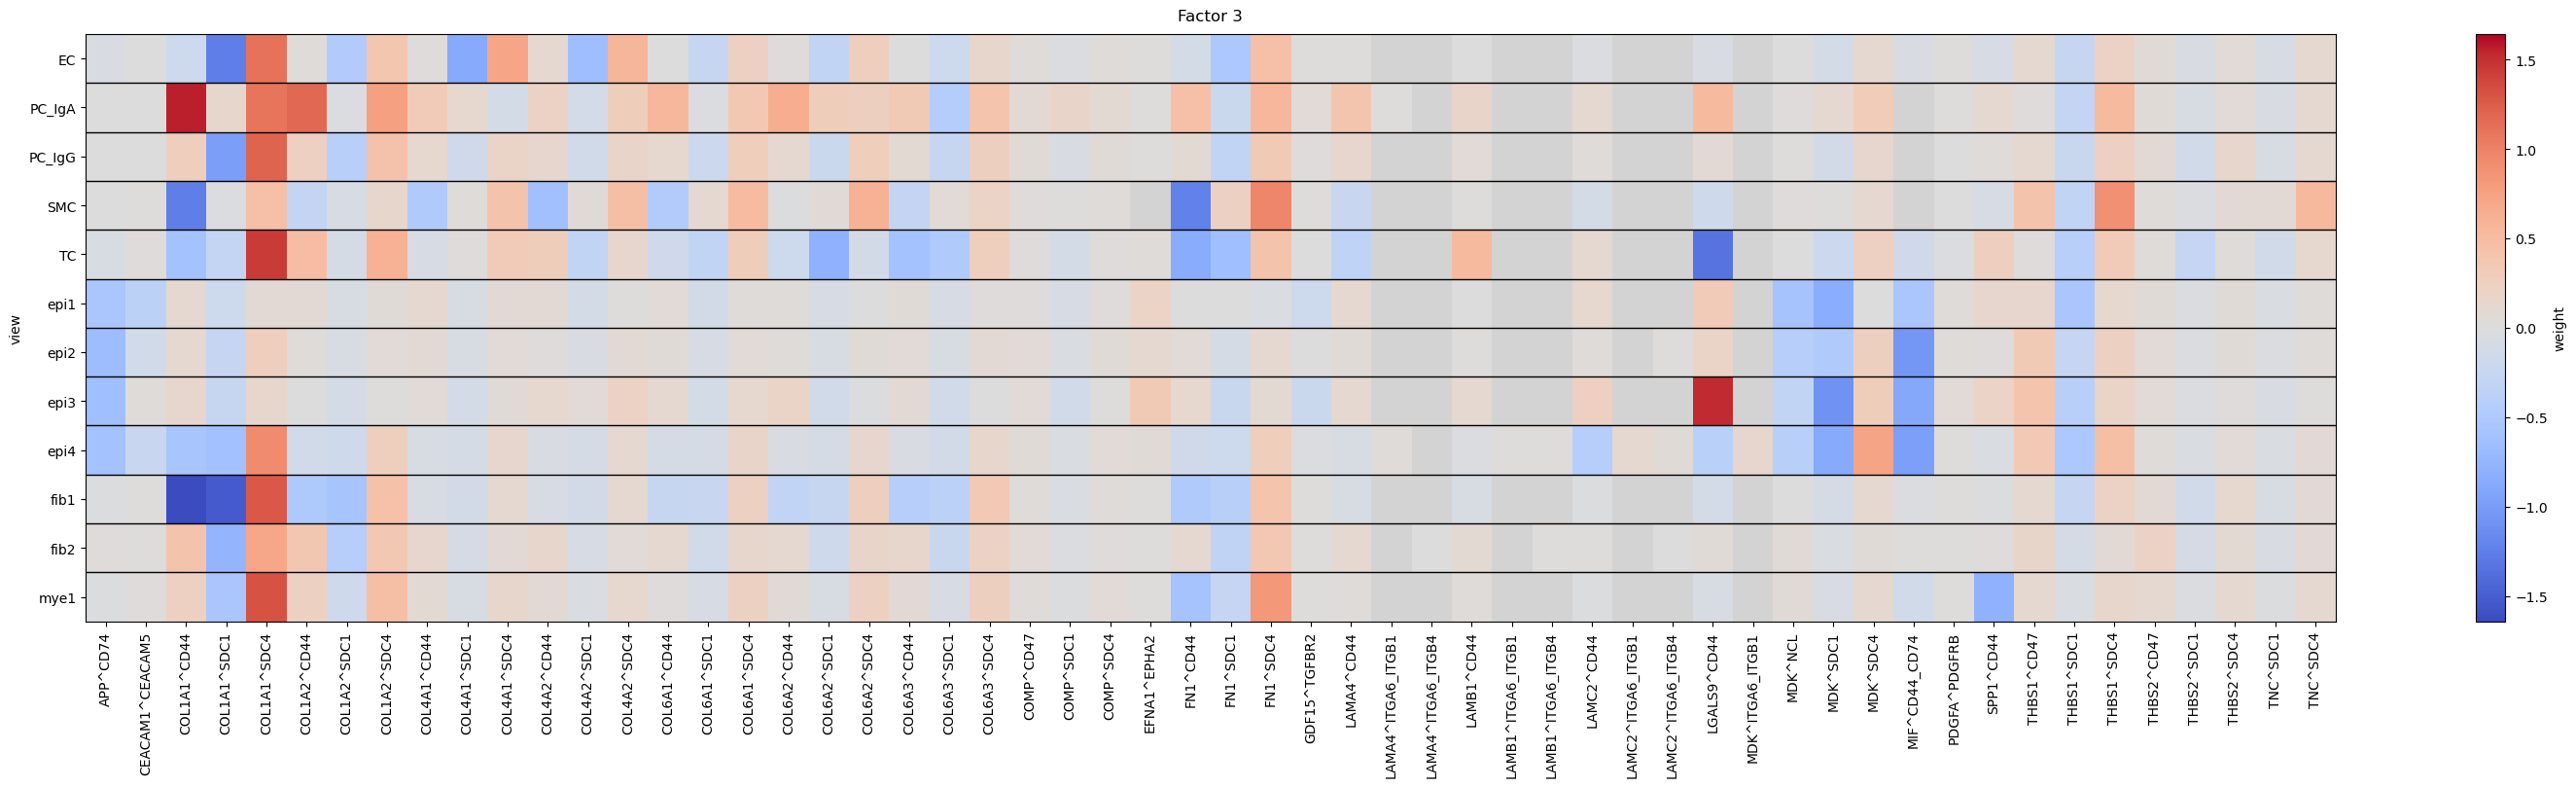

In [67]:
k = 4  # Factor number (1-based)

rows, labels = [], []
for view, df in weights.items():
    s = df.iloc[k-1].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view) 

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# symmetric range + center at 0
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

# (optional) show NaNs in a neutral color
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {k-1}", pad=10)
plt.tight_layout()
plt.show()


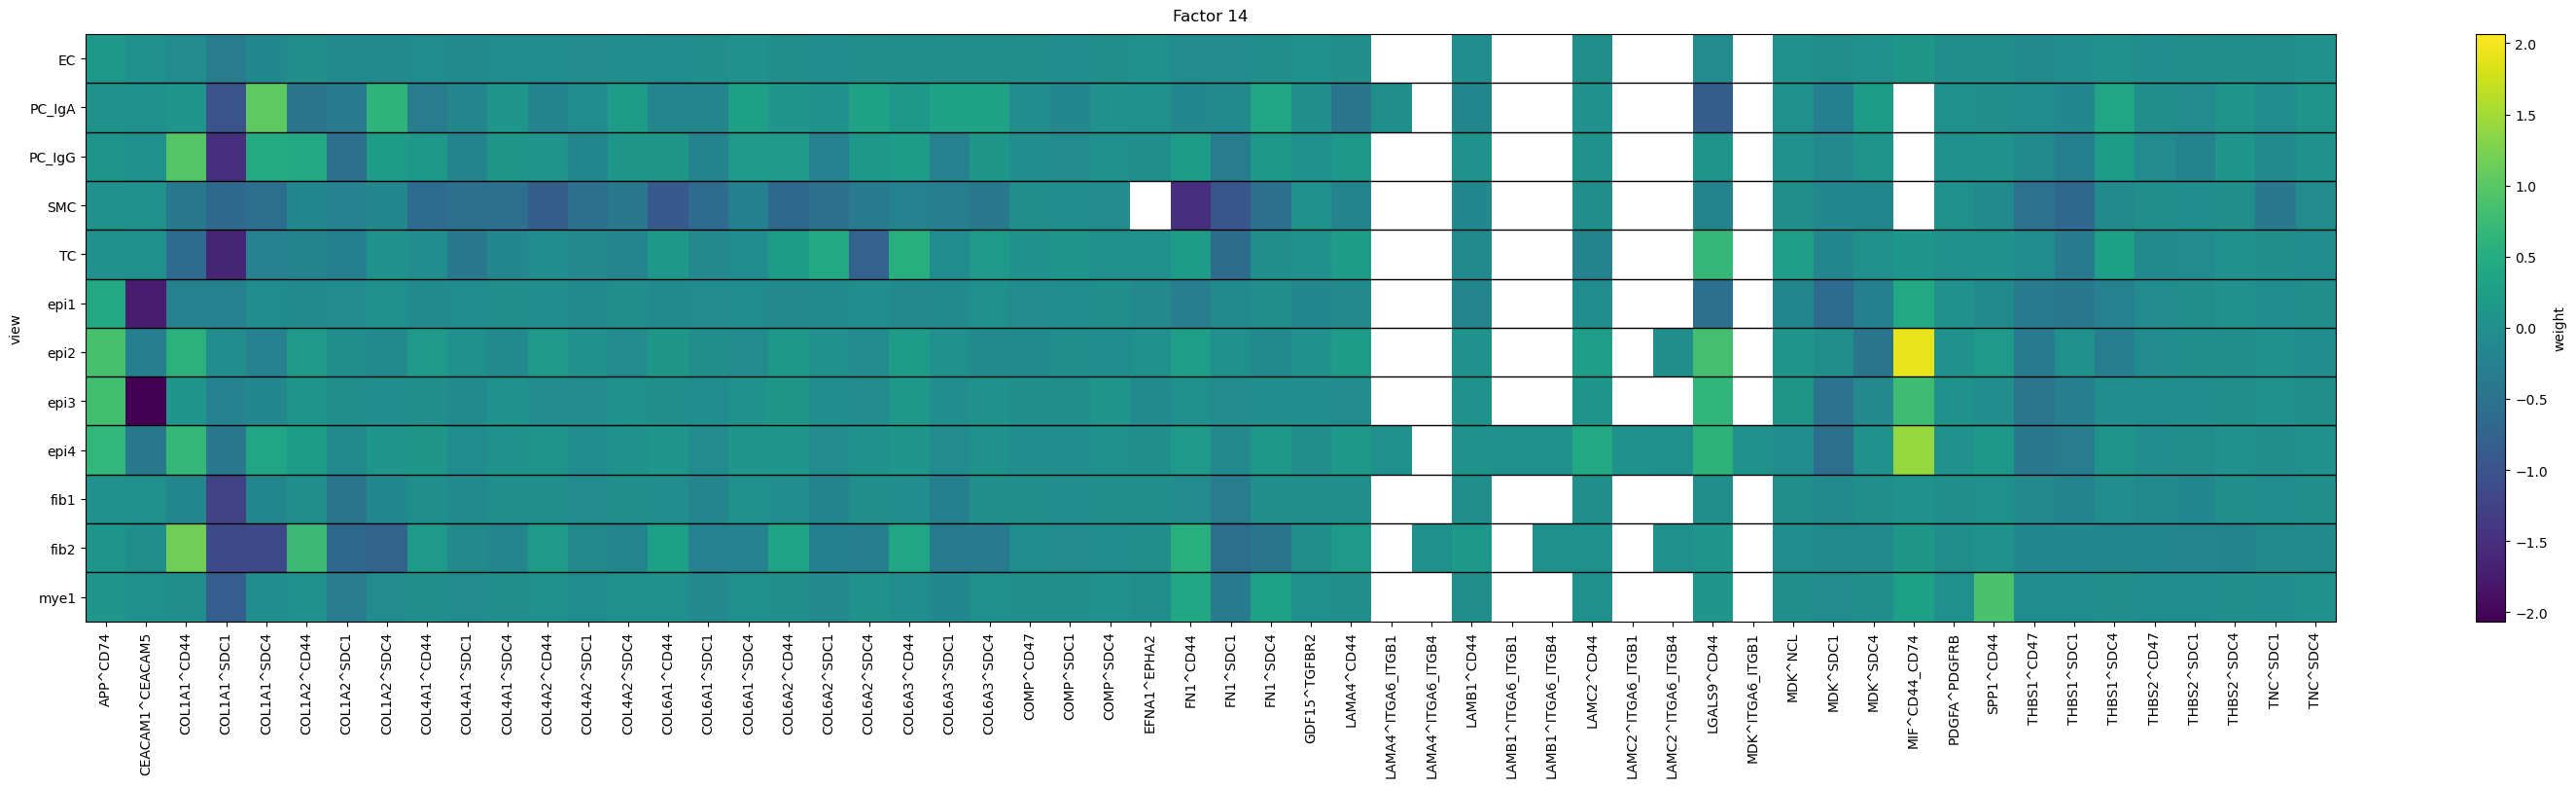

In [44]:
k = 14  # Factor number (1-based)

rows, labels = [], []
for view, df in weights.items():
    s = df.iloc[k-1].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view) 

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))
v = np.nanmax(np.abs(X.values))
im = plt.imshow(X.values, aspect='auto', interpolation='nearest', vmin=-v, vmax=v)
plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")  # <-- y-axis label
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {k}", pad=10)  # or fontsize=14, loc='left'
plt.tight_layout()
plt.show()


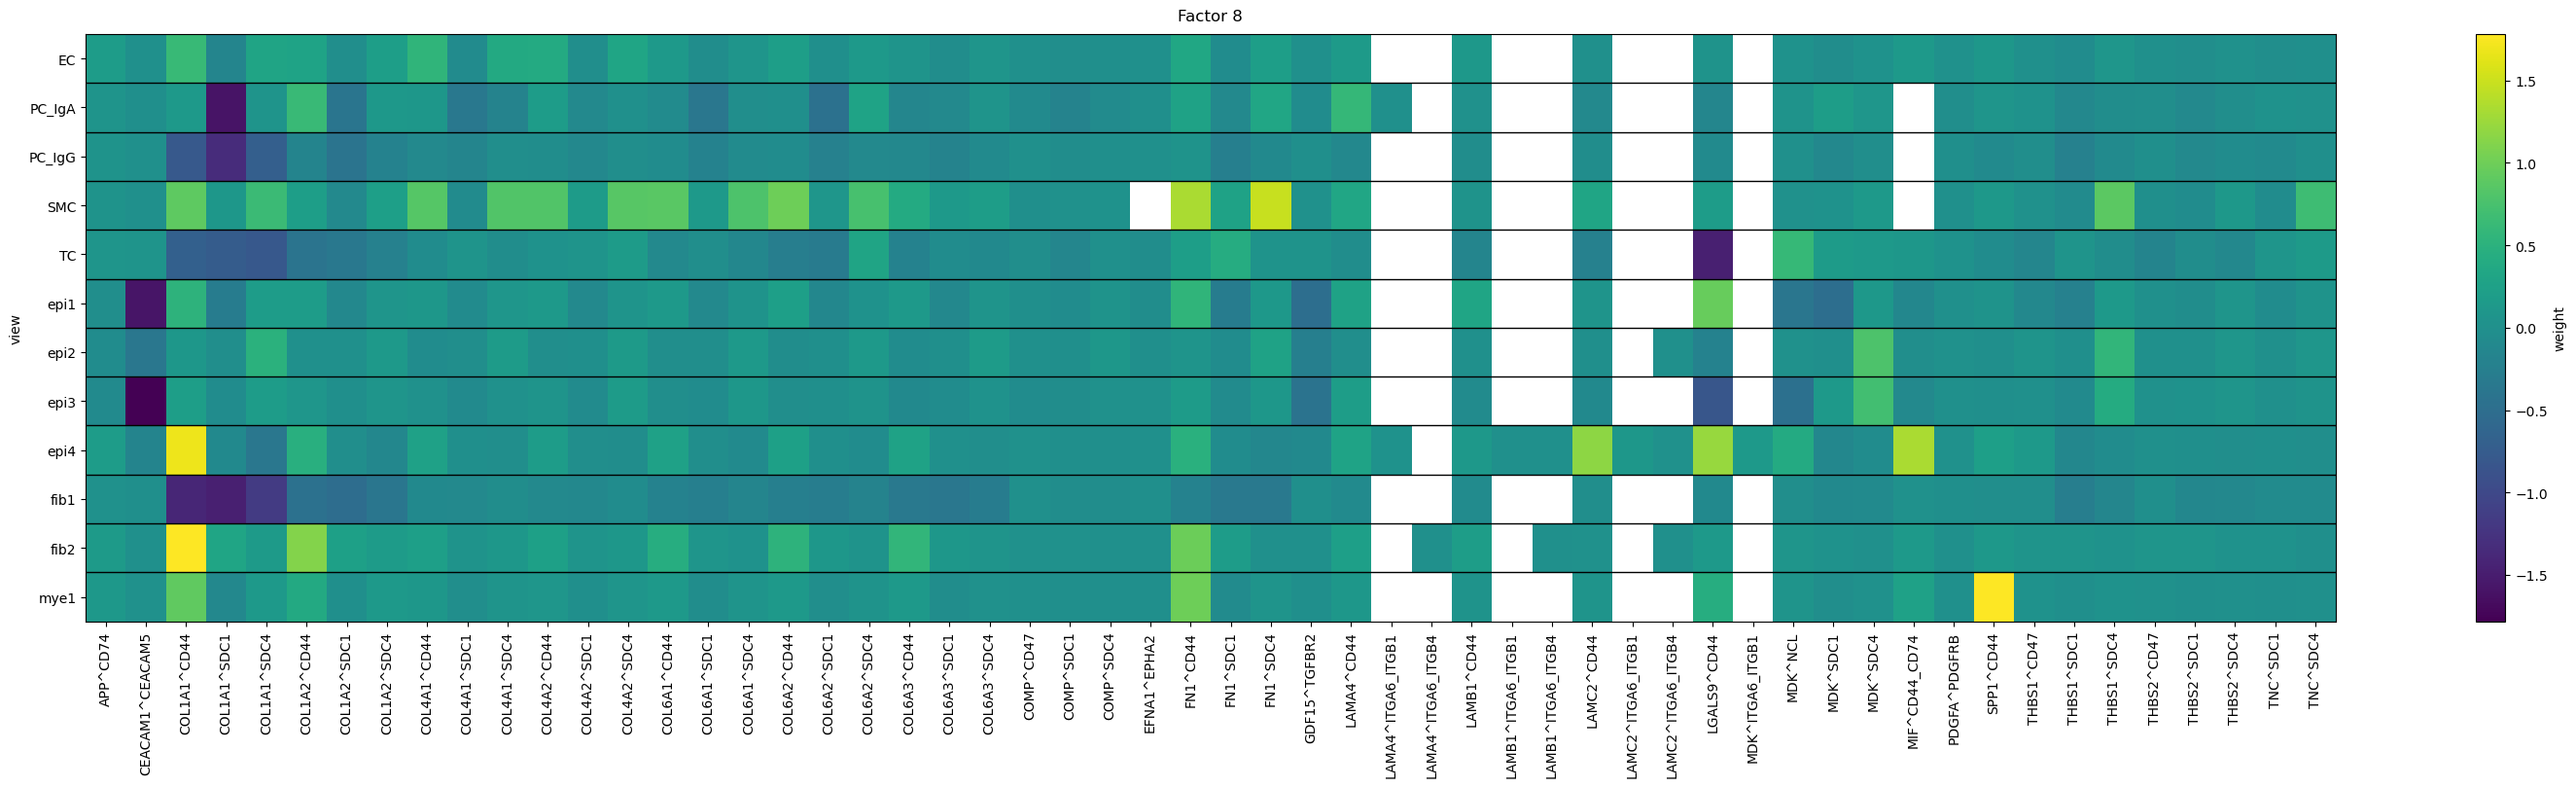

In [45]:
k = 8  # Factor number (1-based)

rows, labels = [], []
for view, df in weights.items():
    s = df.iloc[k-1].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view) 

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))
v = np.nanmax(np.abs(X.values))
im = plt.imshow(X.values, aspect='auto', interpolation='nearest', vmin=-v, vmax=v)
plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")  # <-- y-axis label
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {k}", pad=10)  # or fontsize=14, loc='left'
plt.tight_layout()
plt.show()


# UMAP

In [30]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Standardize factors
scaler = StandardScaler()
scaled_data = scaler.fit_transform(factors)

# Step 2: Apply UMAP (2D)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = reducer.fit_transform(scaled_data)

# Step 3: Put into dataframe with labels
df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'], index=factors.index)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


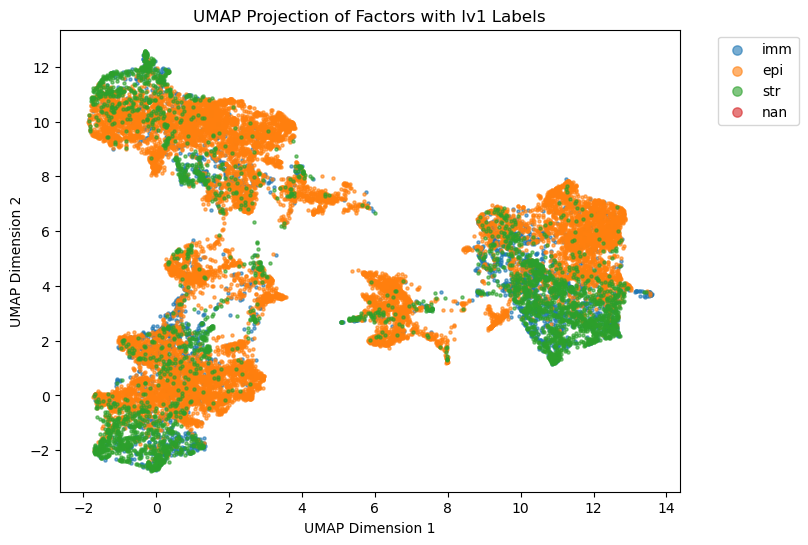

In [31]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [32]:
import hdbscan

X_umap = df_umap[['UMAP1','UMAP2']].values
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)

df_umap['Cluster'] = clusterer.fit_predict(X_umap)


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


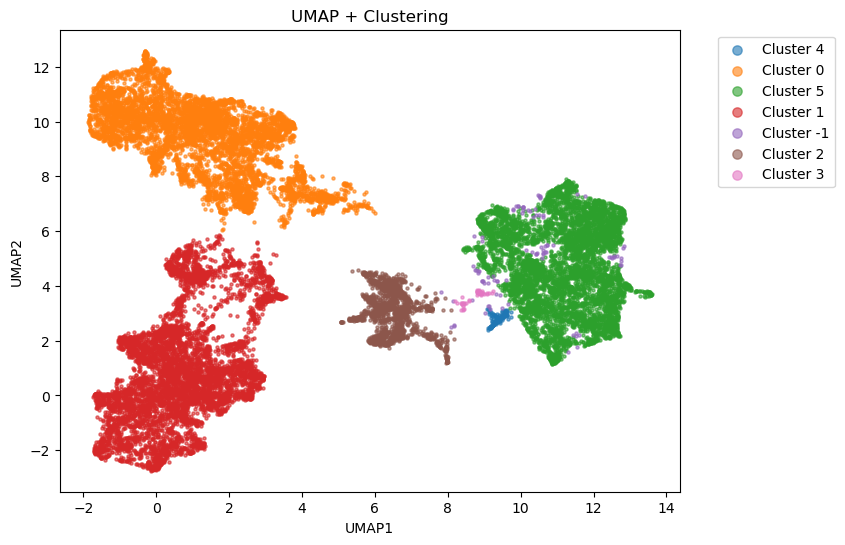

In [34]:
plt.figure(figsize=(8,6))
for cl in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == cl]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=f"Cluster {cl}")

plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

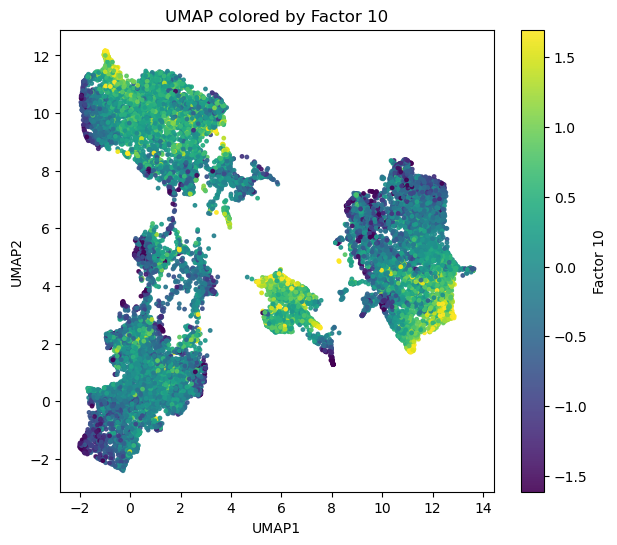

In [38]:
factor_name = "Factor 10"   # <- pick any column from `factors`

vals = factors.loc[df_umap.index, factor_name]           # align by index
vals = vals.astype(float)                                # make sure it's numeric
# (optional) clip extreme values so the color scale isn't dominated by outliers
vmin, vmax = np.percentile(vals.dropna(), [1, 99])

plt.figure(figsize=(7,6))
sc = plt.scatter(df_umap["UMAP1"], df_umap["UMAP2"],
                 c=vals, s=6, alpha=0.9, cmap="viridis",
                 vmin=vmin, vmax=vmax)
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.title(f"UMAP colored by {factor_name}")
cbar = plt.colorbar(sc)
cbar.set_label(factor_name)
plt.show()

In [35]:
# Add cluster info
factors["Cluster"] = df_umap["Cluster"]

In [36]:
# Step 1: Find factor enrichment per cluster
cluster_means = factors.groupby("Cluster").mean()

In [37]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15,Cluster
c_3_154_37,0.085426,0.134153,0.951666,-0.497316,-0.908589,-0.374591,-0.036147,-0.632263,0.179662,-0.087831,-0.317096,-0.290400,-0.670909,1.052463,-0.250754,4
c_3_154_43,0.302522,-0.037855,0.501170,-0.022138,-0.543980,0.097037,-0.099786,-0.351762,0.008662,1.159221,-0.241143,0.153900,-0.198234,0.412840,0.055381,0
c_3_154_61,-0.178582,-0.472574,0.582427,-0.283238,-0.009777,0.253981,-0.307251,-0.313131,0.294228,0.738428,0.273614,-0.370328,-0.259083,-0.293352,0.146010,0
c_3_154_69,-0.112379,-0.095783,-0.310092,0.297999,-0.333418,-0.149187,-0.224769,-0.034862,0.064551,0.672257,0.390976,-0.094665,0.313243,-0.067890,0.682875,0
c_3_154_75,-0.106441,0.214625,-0.231379,-0.212068,-0.355736,-0.345462,-0.624809,0.272327,0.323879,0.334184,0.059619,0.217701,0.450128,-0.164670,0.732304,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_163_214,0.684093,-0.017714,0.160284,-0.627853,-0.033214,-0.165567,-0.473106,0.214921,-0.229451,-0.405425,-0.873117,0.506321,-0.227506,0.103612,0.684636,1
c_3_163_1843,-0.731374,-0.928795,1.742167,-0.319425,-0.465075,0.914405,1.006776,-1.343212,-0.962664,0.106438,1.183348,1.612215,0.053374,0.464126,-0.404423,0
c_3_163_2575,0.756079,-0.996664,-0.594713,-0.554859,-0.038884,-0.083340,0.220243,0.441358,-1.049753,-0.408831,-0.202613,0.400399,-0.462341,-0.193502,-0.109384,1
c_3_164_158,-0.895086,-0.670308,-0.687510,0.233258,1.254605,0.189812,0.107237,-1.204187,0.059344,-0.171521,0.116399,-0.873648,-0.580078,-0.764911,0.933357,1


In [38]:
cluster_means

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
Cluster,,,,,,,,,,,,,,,
-1,-0.091178,-0.055508,0.149004,0.438308,-0.227071,-0.268609,0.231552,0.184402,0.334433,-0.209553,0.113218,-0.538024,-0.288993,0.238336,-0.494780
0,-0.106616,0.025526,0.237074,0.316362,-0.213202,-0.064413,-0.262400,0.151634,-0.214022,0.187152,0.139213,0.451932,0.392839,-0.035824,0.258348
1,0.185427,-0.176885,-0.488241,-0.416028,0.331071,0.334103,-0.087382,-0.233413,-0.195219,-0.183756,-0.250034,-0.124572,-0.086859,-0.219564,0.121981
2,0.314848,0.974129,-0.048339,0.244318,-0.471213,0.263270,0.349483,-0.175765,0.804108,0.603374,-0.729843,0.080929,-0.336596,-0.400143,-0.245610
3,0.494274,0.629518,0.323841,0.735278,0.185693,-0.143229,-0.430290,-0.289565,0.239895,0.198911,-0.402749,-0.806870,0.173663,0.154213,-0.330388
4,0.574890,-0.443117,0.843799,-0.630647,-0.735390,-0.277875,0.471665,-0.782702,0.410662,-0.325368,-0.307704,0.064996,-0.352682,1.186690,-0.443610
5,-0.228916,0.141612,0.171586,-0.029182,-0.132190,-0.291717,0.137535,0.065235,0.382440,-0.013723,0.246749,-0.303189,-0.291297,0.336310,-0.359625


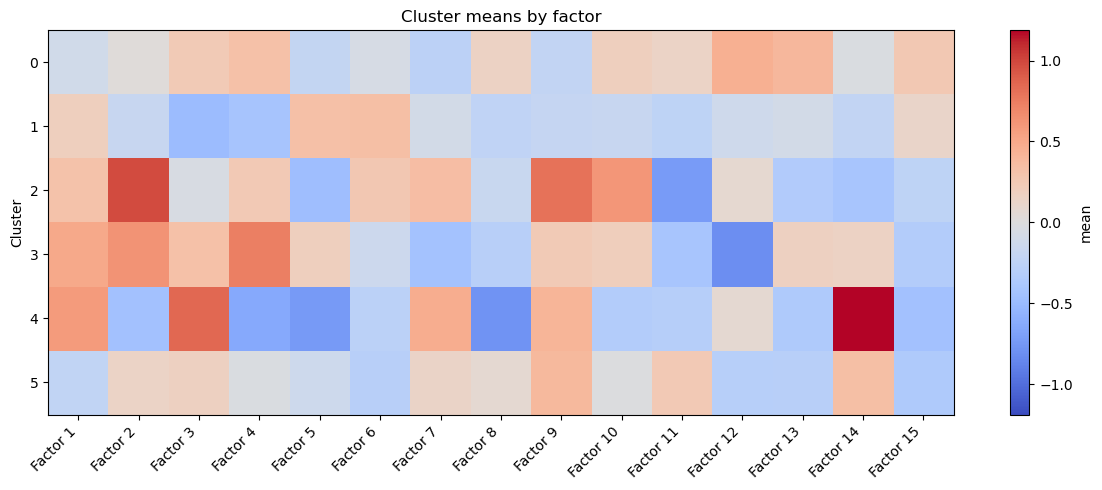

In [43]:
# 1) If -1 is in the index
cm = cluster_means.copy()
cm.index = cm.index.map(lambda x: str(x).strip())   # robust to strings/whitespace
cm = cm.drop(index='-1', errors='ignore')           # or: cm = cm.loc[cm.index != -1]

# 2) If -1 is in a column named "Cluster" (not index), do:
# cm = (cluster_means.query("Cluster != -1")
#                      .set_index("Cluster"))

X = cm.to_numpy()
v = np.nanmax(np.abs(X))
fig, ax = plt.subplots(figsize=(0.6*X.shape[1] + 3, 0.5*X.shape[0] + 2))
im = ax.imshow(X, aspect='auto', vmin=-v, vmax=v, cmap='coolwarm')
ax.set_xticks(range(cm.shape[1])); ax.set_xticklabels(cm.columns, rotation=45, ha='right')
ax.set_yticks(range(cm.shape[0])); ax.set_yticklabels(cm.index)
ax.set_ylabel(cm.index.name or "Cluster"); ax.set_title("Cluster means by factor")
fig.colorbar(im, ax=ax, label="mean")
plt.tight_layout(); plt.show()


## DR in cluster 0

In [43]:
factors["Cluster"] = df_umap["Cluster"]

In [55]:
df_cluster = factors[factors["Cluster"] == 1]

In [56]:
df_cluster = df_cluster.drop(columns=["Cluster"])

In [57]:
df_cluster

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_154_103,-0.410459,-0.034782,-1.177795,-0.245639,-0.014586,-0.290343,-0.162384,0.159430,-0.496310,0.057406,-0.809091,0.061447,0.018892,0.154531,-0.078220
c_3_154_150,0.606788,-0.332608,0.755346,-1.351390,0.829188,0.532743,0.178341,-0.854994,0.181253,0.501617,-0.494431,-1.130911,0.485418,0.338378,-0.368056
c_3_154_175,-0.015974,-0.213190,0.001575,-0.904807,1.137935,0.101756,0.266928,-0.629306,0.221444,0.287387,-0.041342,-1.126161,0.702374,-0.596969,-0.268118
c_3_154_191,-0.176607,0.140500,0.562559,-0.401034,0.314129,0.345198,-0.139444,-0.270097,0.277351,0.391190,0.040825,-1.136908,-0.287696,-0.322578,-0.057523
c_3_154_201,0.012549,0.253310,0.032374,-0.506027,1.084907,0.040940,-1.742825,0.377059,-1.083910,0.551153,0.876300,-0.393066,0.536977,-0.621697,-0.890966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_161_138,0.515645,-1.787719,-0.395172,-0.266157,0.547687,-0.529157,0.864855,0.005056,-0.867053,-0.624578,-0.755359,1.244913,-0.506938,-0.946740,0.813747
c_3_163_214,0.684093,-0.017714,0.160284,-0.627853,-0.033214,-0.165567,-0.473106,0.214921,-0.229451,-0.405425,-0.873117,0.506321,-0.227506,0.103612,0.684636
c_3_163_2575,0.756079,-0.996664,-0.594713,-0.554859,-0.038884,-0.083340,0.220243,0.441358,-1.049753,-0.408831,-0.202613,0.400399,-0.462341,-0.193502,-0.109384
c_3_164_158,-0.895086,-0.670308,-0.687510,0.233258,1.254605,0.189812,0.107237,-1.204187,0.059344,-0.171521,0.116399,-0.873648,-0.580078,-0.764911,0.933357


In [58]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Standardize factors
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

# Step 2: Apply UMAP (2D)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = reducer.fit_transform(scaled_data)

# Step 3: Put into dataframe with labels
df_umap_c0 = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'], index=df_cluster.index)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [59]:
df_umap_c0

,UMAP1,UMAP2
c_3_154_103,7.919484,7.408164
c_3_154_150,10.669086,6.095684
c_3_154_175,10.689885,6.132341
c_3_154_191,10.362948,5.967309
c_3_154_201,11.465404,7.960116
...,...,...
c_3_161_138,12.814652,8.165236
c_3_163_214,7.433709,3.105397
c_3_163_2575,12.673658,8.542024
c_3_164_158,8.216737,4.168778


In [69]:
lv1 = lv1.loc[lv1.index.intersection(df_cluster.index)]
lv1 = lv1.reindex(df_cluster.index)
lv1.shape

(6488,)

In [70]:
ist = ist.loc[ist.index.intersection(df_cluster.index)]
ist = ist.reindex(df_cluster.index)
ist.shape

(6488,)

In [71]:
typ = typ.loc[typ.index.intersection(df_cluster.index)]
typ = typ.reindex(df_cluster.index)
typ.shape

(6488,)

In [76]:
df_umap_c0['Label'] = typ.loc[df_cluster.index].values

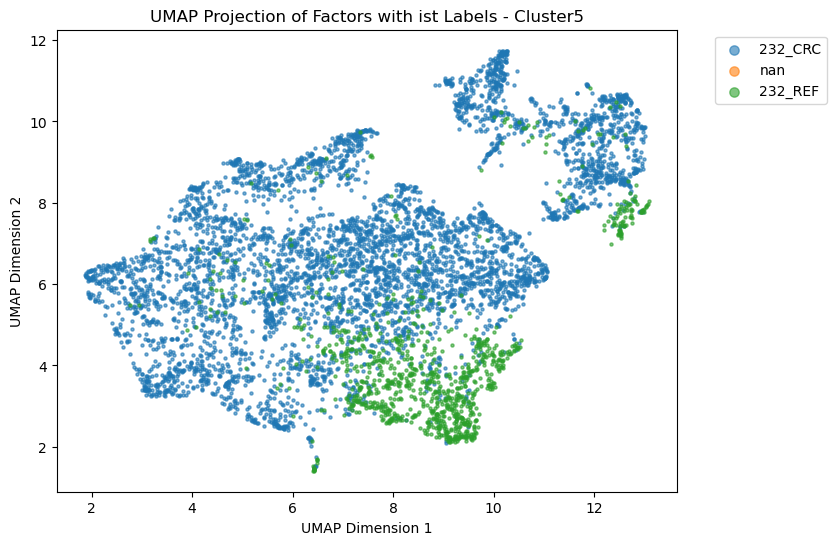

In [77]:
# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap_c0['Label'].unique():
    subset = df_umap_c0[df_umap_c0['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with ist Labels - Cluster5")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Loading Weights 

In [79]:
top_genes_per_cluster = {}

for cl in cluster_means.index:
    # rank factors by absolute enrichment
    ranked_factors = cluster_means.loc[cl].drop("Cluster", errors="ignore").sort_values(
        key=np.abs, ascending=False
    )
    top_factors = ranked_factors.index[:3]  # top 3 strongest factors
    
    cluster_genes = {}
    for f in top_factors:
        cluster_genes[f] = {}
        # go through each view
        for view, w in model_ist.get_weights().items():
            gene_weights = w.loc[f].sort_values(
                key=np.abs, ascending=False
            )
            cluster_genes[f][view] = gene_weights.head(30)  # top 30 genes
    top_genes_per_cluster[cl] = cluster_genes


In [80]:
 model_ist.get_weights().items()

dict_items([('EC',            EC^CEACAM1^CEACAM5  EC^MDK^NCL  EC^APP^CD74  EC^PDGFA^PDGFRB  \
Factor 1             0.000787    0.012454     0.215195         0.012229   
Factor 2             0.002108   -0.003136    -0.050894        -0.011238   
Factor 3            -0.004199   -0.028130     0.090651         0.003401   
Factor 4            -0.003222   -0.000170    -0.062682         0.000970   
Factor 5            -0.008009   -0.039196    -0.166701        -0.001431   
Factor 6             0.008040    0.004715     0.019260        -0.007806   
Factor 7            -0.001425    0.008479     0.141293         0.013601   
Factor 8             0.006539    0.035531     0.184246         0.017374   
Factor 9             0.002488   -0.012392    -0.124671        -0.016246   
Factor 10            0.006109    0.030354     0.060723         0.013177   
Factor 11           -0.015523   -0.066661    -0.186521        -0.006120   
Factor 12           -0.000723   -0.011261    -0.104167        -0.016960   
Factor

In [149]:
 model_ist.get_weights()

{'EC':            EC^CEACAM1^CEACAM5  EC^MDK^NCL  EC^APP^CD74  EC^PDGFA^PDGFRB  \
 Factor 1             0.000787    0.012454     0.215195         0.012229   
 Factor 2             0.002108   -0.003136    -0.050894        -0.011238   
 Factor 3            -0.004199   -0.028130     0.090651         0.003401   
 Factor 4            -0.003222   -0.000170    -0.062682         0.000970   
 Factor 5            -0.008009   -0.039196    -0.166701        -0.001431   
 Factor 6             0.008040    0.004715     0.019260        -0.007806   
 Factor 7            -0.001425    0.008479     0.141293         0.013601   
 Factor 8             0.006539    0.035531     0.184246         0.017374   
 Factor 9             0.002488   -0.012392    -0.124671        -0.016246   
 Factor 10            0.006109    0.030354     0.060723         0.013177   
 Factor 11           -0.015523   -0.066661    -0.186521        -0.006120   
 Factor 12           -0.000723   -0.011261    -0.104167        -0.016960   
 Facto

In [ ]:
from string import ascii_uppercase

: 

In [ ]:


weights = model_ist.get_weights()
k = 3  # factor number (1-based)

rows, labels = [], []
for i, (view, df) in enumerate(weights.items()):
    s = df.iloc[k-1].copy()  # row for Factor 3
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # strip prefix before first ^
    rows.append(s)
    labels.append(ascii_uppercase[i] if i < 26 else f"V{i+1}")  # A, B, ...

X = pd.DataFrame(rows, index=labels)
X = X.reindex(columns=sorted(set().union(*[r.index for r in rows]))).sort_index(axis=1)

plt.figure(figsize=(0.5 * X.shape[1] + 2, 0.6 * X.shape[0] + 1))
v = np.nanmax(np.abs(X.values))
im = plt.imshow(X.values, aspect='auto', interpolation='nearest', vmin=-v, vmax=v)
plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):  # separator between views
    plt.axhline(r - 0.5, color='black', lw=1)
plt.tight_layout()
plt.show()


In [81]:
cluster_genes

{'Factor 12': {'EC': EC^COL1A1^SDC4      1.052549
  EC^COL1A1^CD44     -0.843531
  EC^COL4A1^SDC4      0.778467
  EC^COL4A1^CD44     -0.679908
  EC^COL4A2^SDC4      0.555662
  EC^COL4A2^CD44     -0.529167
  EC^FN1^SDC4         0.477340
  EC^COL1A2^SDC4      0.395569
  EC^FN1^CD44        -0.375095
  EC^COL4A1^SDC1     -0.375057
  EC^COL1A1^SDC1     -0.366960
  EC^COL4A2^SDC1     -0.339250
  EC^COL6A2^CD44     -0.295951
  EC^LAMA4^CD44      -0.280431
  EC^COL6A2^SDC4      0.267175
  EC^COL1A2^CD44     -0.256188
  EC^LGALS9^CD44     -0.233973
  EC^COL6A1^SDC4      0.231002
  EC^COL6A1^CD44     -0.204080
  EC^THBS1^SDC4       0.192860
  EC^FN1^SDC1        -0.178717
  EC^COL1A2^SDC1     -0.170283
  EC^COL6A3^SDC4      0.149637
  EC^COL6A2^SDC1     -0.142638
  EC^LAMB1^CD44      -0.139363
  EC^COL6A1^SDC1     -0.133654
  EC^COL6A3^CD44     -0.128253
  EC^MDK^SDC4         0.117882
  EC^APP^CD74        -0.104167
  EC^MIF^CD44_CD74   -0.103684
  Name: Factor 12, dtype: float32,
  'PC_IgA': PC_I

In [222]:
cluster_genes

{'Factor 9': {'EC': EC^COL1A1^SDC4       -1.297660
  EC^COL1A1^SDC1       -0.949313
  EC^COL4A1^SDC4       -0.794052
  EC^COL4A1^SDC1       -0.733924
  EC^COL4A2^SDC4       -0.602770
  EC^COL4A2^SDC1       -0.598538
  EC^FN1^SDC4          -0.580152
  EC^FN1^SDC1          -0.432382
  EC^COL1A2^SDC1       -0.423238
  EC^COL1A2^SDC4       -0.390899
  EC^COL6A2^SDC4       -0.323404
  EC^COL6A2^SDC1       -0.305590
  EC^COL6A1^SDC4       -0.231844
  EC^THBS1^SDC4        -0.218452
  EC^COL6A1^SDC1       -0.193114
  EC^COL6A3^SDC1       -0.139604
  EC^MDK^SDC4          -0.130895
  EC^COL1A1^CD44       -0.126134
  EC^APP^CD74          -0.124671
  EC^COL6A3^SDC4       -0.123207
  EC^THBS1^CD47         0.116527
  EC^TNC^SDC4          -0.086485
  EC^THBS1^SDC1        -0.076132
  EC^LAMA4^CD44         0.060634
  EC^THBS2^SDC4        -0.056616
  EC^MDK^SDC1          -0.050846
  EC^LAMB1^CD44         0.049296
  EC^THBS2^CD47         0.048830
  EC^COL6A3^CD44        0.046804
  EC^LGALS9^CD44       -0

In [82]:
top_genes_per_cluster

{-1: {'Factor 2': {'EC': EC^COL1A1^SDC1   -0.986356
   EC^COL1A1^SDC4   -0.955787
   EC^COL4A1^SDC1   -0.644277
   EC^COL4A1^SDC4   -0.596351
   EC^COL4A2^SDC1   -0.476714
   EC^COL4A2^SDC4   -0.454562
   EC^COL1A2^SDC1   -0.408596
   EC^COL1A2^SDC4   -0.332658
   EC^COL4A1^CD44   -0.297876
   EC^FN1^SDC1      -0.275185
   EC^COL4A2^CD44   -0.273102
   EC^FN1^SDC4      -0.252351
   EC^COL1A1^CD44   -0.202980
   EC^COL6A2^SDC4   -0.198703
   EC^THBS1^SDC4    -0.195388
   EC^COL6A1^SDC1   -0.186269
   EC^THBS1^SDC1    -0.183983
   EC^COL6A2^SDC1   -0.178516
   EC^COL6A3^SDC4   -0.146269
   EC^COL1A2^CD44   -0.143850
   EC^COL6A1^SDC4   -0.132192
   EC^COL6A3^SDC1   -0.131255
   EC^MDK^SDC1      -0.093086
   EC^MDK^SDC4      -0.087190
   EC^THBS1^CD47     0.082514
   EC^THBS2^SDC4    -0.068295
   EC^COL6A2^CD44   -0.064722
   EC^TNC^SDC4      -0.063647
   EC^LAMA4^CD44    -0.058953
   EC^THBS2^SDC1    -0.056196
   Name: Factor 2, dtype: float32,
   'PC_IgA': PC_IgA^COL1A1^SDC1   -0.974677

In [84]:
rows = []

for cl, factor_dict in top_genes_per_cluster.items():
    for f, view_dict in factor_dict.items():
        for view, genes in view_dict.items():
            # take the single top gene (highest weight)
            top_gene = genes.index[0]
            top_weight = genes.iloc[0]
            rows.append({
                "Cluster": cl,
                "View": view,
                "Factor": f,
                "TopGene": top_gene,
                "Weight": top_weight
            })

df_top = pd.DataFrame(rows)

In [140]:
df_top[df_top["Cluster"] == 1].sort_values('Weight', ascending=False)

,Cluster,View,Factor,TopGene,Weight
81,1,fib1,Factor 3,fib1^COL1A1^CD44,2.125598
74,1,PC_IgG,Factor 3,PC_IgG^COL1A1^CD44,1.729479
76,1,TC,Factor 3,TC^FN1^CD44,1.595207
72,1,EC,Factor 3,EC^COL1A1^CD44,1.577549
85,1,PC_IgA,Factor 4,PC_IgA^COL1A1^CD44,1.561152
91,1,epi3,Factor 4,epi3^LGALS9^CD44,1.516413
100,1,TC,Factor 6,TC^COL1A1^SDC1,1.497602
83,1,mye1,Factor 3,mye1^SPP1^CD44,1.477201
88,1,TC,Factor 4,TC^COL1A1^SDC4,1.441490
80,1,epi4,Factor 3,epi4^MDK^SDC4,1.325380


In [ ]:
df_top_sorted = df_top.sort_values("Weight", ascending=False)

df_top_sorted.style.set_table_attributes(
    'style="display:inline;overflow:auto;height:300px;width:800px;"'
).set_table_styles([
    dict(selector="tbody", props=[("overflow", "auto")])
])


## Check gene in original data

In [141]:
gene = "fib1^COL1A1^CD44"

In [142]:
group = "ist"

In [143]:
lrdata

AnnData object with n_obs × n_vars = 129915 × 690
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_

In [144]:
df = lrdata.to_df() 
df = df[[gene]].join(lrdata.obs[group])

In [145]:
totals = df.groupby(df[group])[gene].sum()
print(totals)  # index = cell types, values = total expression


ist
EC         345.379201
epi1       103.880834
epi2       437.756332
epi3        56.742294
epi4       362.641056
fib1      1573.025683
fib2       785.829966
mye1       647.290235
mye2        26.301410
PC_IgA      77.326186
PC_IgG     715.833090
PC_IgM      28.679973
SMC        136.295950
TC         228.769182
Name: fib1^COL1A1^CD44, dtype: float64


/scratch/jobs/37250679/ipykernel_1845228/3657553524.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [146]:
agg = df.groupby(df[group])[gene].agg(total="sum", mean="mean", median="median", n="count")
print(agg)


              total      mean  median      n
ist                                         
EC       345.379201  0.047209     0.0   7316
epi1     103.880834  0.005637     0.0  18428
epi2     437.756332  0.024137     0.0  18136
epi3      56.742294  0.015640     0.0   3628
epi4     362.641056  0.036130     0.0  10037
fib1    1573.025683  0.097613     0.0  16115
fib2     785.829966  0.091216     0.0   8615
mye1     647.290235  0.120225     0.0   5384
mye2      26.301410  0.024650     0.0   1067
PC_IgA    77.326186  0.017916     0.0   4316
PC_IgG   715.833090  0.064911     0.0  11028
PC_IgM    28.679973  0.022672     0.0   1265
SMC      136.295950  0.020318     0.0   6708
TC       228.769182  0.047453     0.0   4821


/scratch/jobs/37250679/ipykernel_1845228/593184640.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


/scratch/jobs/37250679/ipykernel_1845228/3517884222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


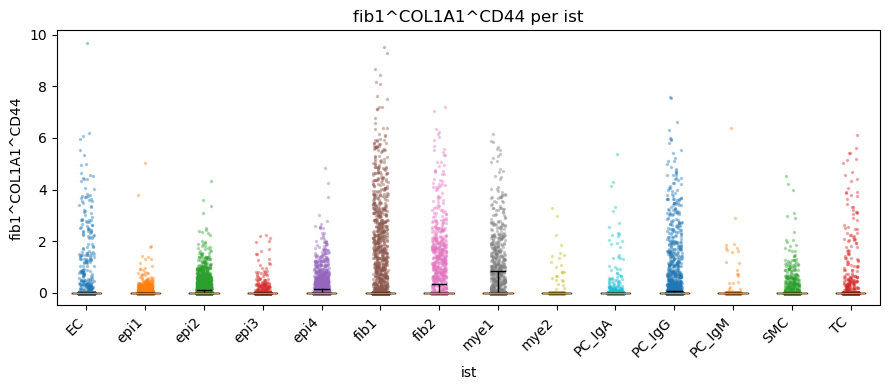

In [147]:
# Order groups by median (nice for readability)
order = (df.groupby(group)[gene]
           .median()
           .sort_values(ascending=False)
           .index.tolist())

fig, ax = plt.subplots(figsize=(9,4))

# Jittered dots per group
for i, g in enumerate(order, start=1):
    y = df.loc[df[group] == g, gene].to_numpy()
    x = i + (np.random.random(y.size) - 0.5) * 0.25  # jitter width
    ax.plot(x, y, ".", alpha=0.3, markersize=3, rasterized=True)

# (Optional) add a boxplot underneath
ax.boxplot([df.loc[df[group]==g, gene].to_numpy() for g in order],
           positions=range(1, len(order)+1),
           showfliers=False, whis=(5,95))

ax.set_xticks(range(1, len(order)+1)); ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_xlabel(group); ax.set_ylabel(gene); ax.set_title(f"{gene} per {group}")
plt.tight_layout()


# t-SNE

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20377 samples in 0.049s...
[t-SNE] Computed neighbors for 20377 samples in 7.818s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20377
[t-SNE] Computed conditional probabilities for sample 2000 / 20377
[t-SNE] Computed conditional probabilities for sample 3000 / 20377
[t-SNE] Computed conditional probabilities for sample 4000 / 20377
[t-SNE] Computed conditional probabilities for sample 5000 / 20377
[t-SNE] Computed conditional probabilities for sample 6000 / 20377
[t-SNE] Computed conditional probabilities for sample 7000 / 20377
[t-SNE] Computed conditional probabilities for sample 8000 / 20377
[t-SNE] Computed conditional probabilities for sample 9000 / 20377
[t-SNE] Computed conditional probabilities for sample 10000 / 20377
[t-SNE] Computed conditional probabilities for sample 11000 / 20377
[t-SNE] Computed conditional probabilities for sample 12000 / 20377
[t-SNE] Computed conditional probabilities for sam

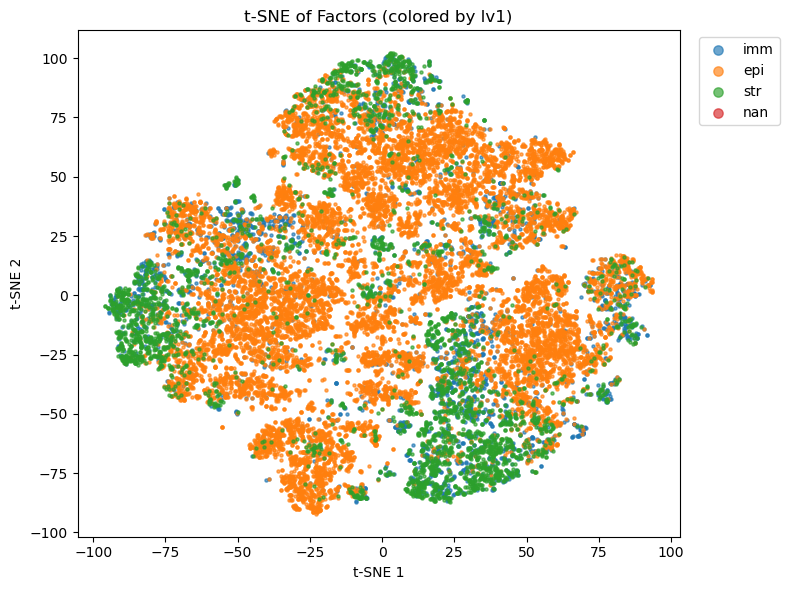

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# factors: DataFrame with 15 columns (Factor 1...Factor 15), ~20k rows
# lv1: Series/DataFrame of labels with the same index as `factors`

X = factors.astype(float).copy()

# 1) Standardize
X_std = StandardScaler().fit_transform(X)

# 2) Optional but recommended: PCA to ~30 comps (or <= original dims)
n_pca = min(30, X.shape[1])
X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_std)

# 3) t-SNE to 2D (good defaults for ~20k rows; tweak if needed)
tsne = TSNE(
    n_components=2,
    perplexity=30,          # try 5–50; larger == more global structure
    learning_rate='auto',   # lets sklearn set a good value
    init='pca',             # stable starting point
    early_exaggeration=12,  # 8–24 is typical
    n_iter=1000,            # 750–3000; more = slower but crisper
    angle=0.5,              # Barnes–Hut speed/accuracy tradeoff (0.2–0.8)
    random_state=42,
    verbose=1
)
Y = tsne.fit_transform(X_pca)

# 4) Put in a DataFrame and align labels
emb = pd.DataFrame(Y, columns=['tSNE1','tSNE2'], index=factors.index)
emb['Label'] = lv1.loc[emb.index].values

# 5) Plot
plt.figure(figsize=(8,6))
for lbl in emb['Label'].unique():
    s = emb[emb['Label'] == lbl]
    plt.scatter(s['tSNE1'], s['tSNE2'], s=5, alpha=0.65, label=str(lbl))
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.title('t-SNE of Factors (colored by lv1)')
plt.legend(markerscale=3, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()
